In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from functools import reduce
import matplotlib.patches as mpatches
from matplotlib import ticker
from sklearn.linear_model import LinearRegression


In [3]:
# Lee tus archivos uno a uno (ajusta los nombres exactos)
alquiler_vivienda = pd.read_csv(r"C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto EDA\EDA Correlacion del precio de la vivienda respecto al oro\data\processed\alquiler_vivienda_definitivo.csv")
compraventas = pd.read_csv(r"C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto EDA\EDA Correlacion del precio de la vivienda respecto al oro\data\processed\compraventas_anual_final.csv",sep=';')
euribor = pd.read_csv(r"C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto EDA\EDA Correlacion del precio de la vivienda respecto al oro\data\processed\euribor_final.csv")
ipc = pd.read_csv(r"C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto EDA\EDA Correlacion del precio de la vivienda respecto al oro\data\processed\IPC_final.csv")
oro = pd.read_csv(r"C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto EDA\EDA Correlacion del precio de la vivienda respecto al oro\data\processed\oro_final.csv")
poder_adquisitivo = pd.read_csv(r"C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto EDA\EDA Correlacion del precio de la vivienda respecto al oro\data\processed\poder_adquisitivo_final.csv")
precio_viviendas = pd.read_csv(r"C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto EDA\EDA Correlacion del precio de la vivienda respecto al oro\data\processed\precio_vivienda_final.csv")
tipos_interes = pd.read_csv(r"C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto EDA\EDA Correlacion del precio de la vivienda respecto al oro\data\processed\tipos_interes_final.csv")

In [4]:
precio_viviendas.head()

,DateTime,Precio €/m2,Variación anual,Anio
0,2026-02-01,2673,"17,70%",2026
1,2026-01-01,2650,"18,40%",2026
2,2025-12-01,2639,"16,20%",2025
3,2025-11-01,2605,"16,10%",2025
4,2025-10-01,2555,"15,70%",2025


In [5]:
ipc.head()

,DateTime,VALOR,Anio
0,2026-02-01,"0,4",2026
1,2026-01-01,"-0,4",2026
2,2025-12-01,"0,3",2025
3,2025-11-01,"0,2",2025
4,2025-10-01,"0,7",2025


In [ ]:
def limpiar_numero(columna):
    # Convertimos a string por si acaso, quitamos espacios, cambiamos coma por punto
    # y eliminamos símbolos comunes
    return pd.to_numeric(
        columna.astype(str)
               .str.replace('.', '', regex=False) # Quitar separador de miles si existe
               .str.replace(',', '.', regex=False) # Cambiar coma decimal por punto
               .str.extract(r'([-+]?\d*\.?\d+)')[0], # Extraer solo el número
        errors='coerce'
    )

# 2. APLICAR LIMPIEZA
# Limpiamos el IPC
ipc['VALOR'] = limpiar_numero(ipc['VALOR'])

# Limpiamos la Variación de la Vivienda (ya que viene como string)
precio_viviendas['Variación anual'] = limpiar_numero(precio_viviendas['Variación anual'])

# 3. CÁLCULO Y MERGE
ipc = ipc.sort_values('Anio')
ipc['Var_Anual_IPC'] = ipc['VALOR'].pct_change() * 100

vivienda_ipc = pd.merge(
    precio_viviendas[['Anio', 'Variación anual']], 
    ipc[['Anio', 'Var_Anual_IPC']], 
    on='Anio', 
    how='inner'
).dropna() # Quitamos el primer año que será NaN por el pct_change


In [7]:
vivienda_ipc.head()

,Anio,Variación anual,Var_Anual_IPC
0,2026,17.7,33.333333
1,2026,17.7,-200.000000
2,2026,18.4,33.333333
3,2026,18.4,-200.000000
4,2025,16.2,-125.000000


In [8]:
# 1. Creamos una columna de 'Diferencial' (Vivienda - IPC)
# Si es positivo, la vivienda batió a la inflación ese año.
vivienda_ipc['Diferencial'] = vivienda_ipc['Variación anual'] - vivienda_ipc['Var_Anual_IPC']

In [9]:
vivienda_ipc.describe() #Las comas en el valor del IPC me desvirtuan todas las medias

c:\Users\Eneko\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
c:\Users\Eneko\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


,Anio,Variación anual,Var_Anual_IPC,Diferencial
count,2680.000000,2680.000000,2680.000000,2680.000000
mean,2015.956716,1.074590,NaN,NaN
std,5.457733,5.788858,NaN,NaN
min,2007.000000,-11.100000,-inf,-inf
25%,2011.000000,-2.800000,-175.000000,-10.625000
50%,2016.000000,1.300000,-80.000000,84.214286
75%,2021.000000,4.600000,9.090909,173.525000
max,2026.000000,18.400000,inf,inf


In [ ]:
# 1. Limpieza específica para el formato "0,4"
def limpiar_ipc(valor):
    if pd.isna(valor): return np.nan
    # Cambiamos coma por punto y convertimos a número
    return float(str(valor).replace(',', '.'))

# Aplicamos la limpieza al valor original
ipc['VALOR_Limpio'] = ipc['VALOR'].apply(limpiar_ipc)

# 2. Agrupamos por año para obtener la variación media anual real
df_ipc_anual = ipc.groupby('Anio')['VALOR_Limpio'].mean().reset_index()
df_ipc_anual.columns = ['Anio', 'Var_Anual_IPC']

# 3. Merge con el dataframe de vivienda
df_final = pd.merge(
    precio_viviendas[['Anio', 'Variación anual']], 
    df_ipc_anual, 
    on='Anio', 
    how='inner'
)

# 4. Filtro de seguridad para eliminar errores de bulto (outliers)
df_final = df_final[df_final['Variación anual'].between(-30, 30)]
df_final = df_final[df_final['Var_Anual_IPC'].between(-15, 15)]

print("Nuevos datos limpios:")
print(df_final.describe())

Nuevos datos limpios:
              Anio  Variación anual  Var_Anual_IPC
count   228.000000       228.000000     228.000000
mean   2016.013158         1.157895       0.170687
std       5.511286         5.951040       0.159002
min    2007.000000       -11.100000      -0.075000
25%    2011.000000        -2.850000       0.066667
50%    2016.000000         1.300000       0.133333
75%    2021.000000         4.600000       0.250000
max    2026.000000        18.400000       0.533333


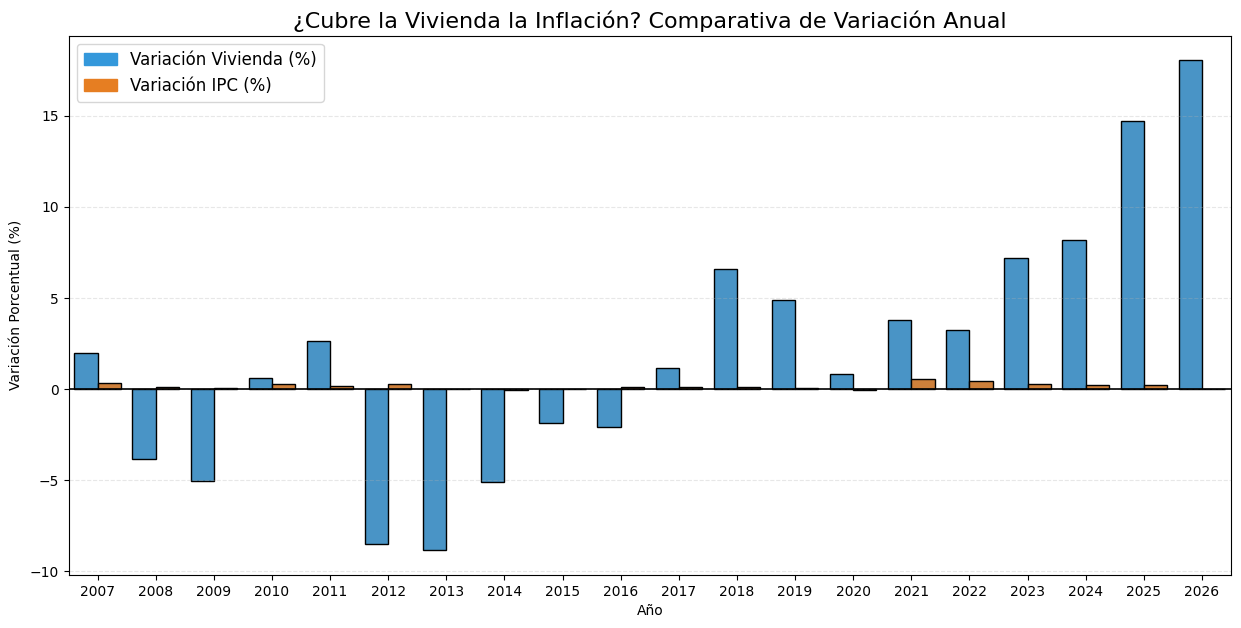

In [11]:
# 1. Agrupamos por año para tener un solo dato por ejercicio (Mediana)
df_barras = df_final.groupby('Anio')[['Variación anual', 'Var_Anual_IPC']].median().reset_index()
df_barras['Anio'] = df_barras['Anio'].astype(int)

# 2. Configuración visual
plt.figure(figsize=(15, 7))
color_vivienda = '#3498db' # Azul
color_ipc = '#e67e22'      # Naranja

# Transformamos a formato largo para Seaborn
df_plot = df_barras.melt(id_vars='Anio', value_vars=['Variación anual', 'Var_Anual_IPC'])

# 3. Dibujamos las barras
sns.barplot(
    data=df_plot, 
    x='Anio', 
    y='value', 
    hue='variable', 
    palette=[color_vivienda, color_ipc],
    edgecolor='black'
)

# 4. Leyenda personalizada con cuadrados sólidos
azul_patch = mpatches.Patch(color=color_vivienda, label='Variación Vivienda (%)')
naranja_patch = mpatches.Patch(color=color_ipc, label='Variación IPC (%)')
plt.legend(handles=[azul_patch, naranja_patch], loc='upper left', fontsize=12)

# 5. Detalles de interpretación
plt.axhline(0, color='black', linewidth=1.2) # Línea de base
plt.title('¿Cubre la Vivienda la Inflación? Comparativa de Variación Anual', fontsize=16)
plt.ylabel('Variación Porcentual (%)')
plt.xlabel('Año')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

In [12]:
oro.head()

,DateTime,oro_media_mensual,Anio
0,2016-04-01,1102.007590,2016
1,2016-05-01,1112.271385,2016
2,2016-06-01,1135.730955,2016
3,2016-07-01,1209.335225,2016
4,2016-08-01,1193.973885,2016


In [13]:
# 1. Asegurar que el Precio de la Vivienda sea numérico
# Eliminamos posibles puntos de miles o símbolos si los hubiera
precio_viviendas['Precio €/m2'] = pd.to_numeric(
    precio_viviendas['Precio €/m2'].astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .str.extract(r'(\d+\.?\d*)')[0], 
    errors='coerce'
)

# 2. Recalculamos la agrupación del Oro
df_oro_anual = oro.groupby('Anio')['oro_media_mensual'].median().reset_index()
df_oro_anual.columns = ['Anio', 'Precio_Oro_Onza']

# 3. Merge y Cálculo del Ratio
df_oro_vivienda = pd.merge(
    precio_viviendas[['Anio', 'Precio €/m2', 'Variación anual']], 
    df_oro_anual, 
    on='Anio', 
    how='inner'
)

df_oro_vivienda['Ratio_Vivienda_Oro'] = df_oro_vivienda['Precio €/m2'] / df_oro_vivienda['Precio_Oro_Onza']

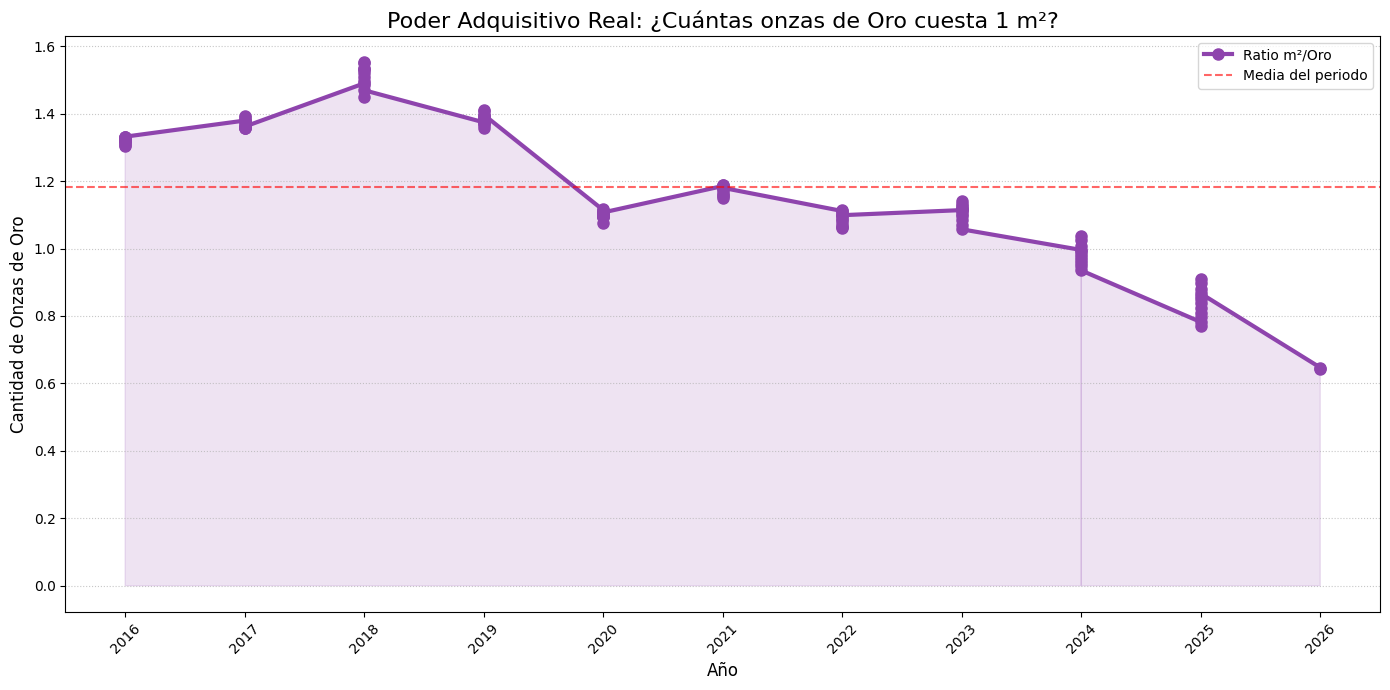

Datos graficados (Primeros años):
     Anio  Precio €/m2  Precio_Oro_Onza  Ratio_Vivienda_Oro
119  2016       1522.0      1142.721343            1.331908
118  2016       1518.0      1142.721343            1.328408
113  2016       1491.0      1142.721343            1.304780
112  2016       1494.0      1142.721343            1.307405
111  2016       1501.0      1142.721343            1.313531


In [14]:
# 1. Filtramos y ordenamos, asegurando que existan datos
df_crisis = df_oro_vivienda[df_oro_vivienda['Anio'] >= 2008].sort_values('Anio')

if df_crisis.empty:
    print("Error: No hay datos disponibles para el año 2008 o posteriores en el merge actual.")
else:
    # 2. Configuración del gráfico
    plt.figure(figsize=(14, 7))

    # Línea del Ratio (Onzas por m2)
    plt.plot(df_crisis['Anio'].astype(int), df_crisis['Ratio_Vivienda_Oro'], 
             marker='o', color='#8e44ad', linewidth=3, markersize=8, label='Ratio m²/Oro')

    # Relleno visual
    plt.fill_between(df_crisis['Anio'].astype(int), df_crisis['Ratio_Vivienda_Oro'], 
                     alpha=0.15, color='#8e44ad')

    # 3. Forzamos los años en el eje X para que no haya decimales
    años_disponibles = df_crisis['Anio'].unique().astype(int)
    plt.xticks(años_disponibles, rotation=45)

    # 4. Títulos y etiquetas
    plt.title('Poder Adquisitivo Real: ¿Cuántas onzas de Oro cuesta 1 m²?', fontsize=16)
    plt.ylabel('Cantidad de Onzas de Oro', fontsize=12)
    plt.xlabel('Año', fontsize=12)

    # Añadimos la media del periodo
    media_ratio = df_crisis['Ratio_Vivienda_Oro'].mean()
    plt.axhline(media_ratio, color='red', linestyle='--', alpha=0.6, label='Media del periodo')

    plt.legend()
    plt.grid(True, axis='y', linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Mostramos los primeros años para verificar qué datos tenemos
    print("Datos graficados (Primeros años):")
    print(df_crisis[['Anio', 'Precio €/m2', 'Precio_Oro_Onza', 'Ratio_Vivienda_Oro']].head())

In [15]:
euribor.head()

,Fecha,Media mensual (%),mes_en,anio_num,DateTime,Anio
0,ene-99,3.062,Jan,99,1999-01-01,1999
1,feb-99,3.030,Feb,99,1999-02-01,1999
2,mar-99,3.046,Mar,99,1999-03-01,1999
3,abr-99,2.756,Apr,99,1999-04-01,1999
4,may-99,2.683,May,99,1999-05-01,1999


In [16]:
# 1. Limpieza y Agrupación del Euríbor
# Usamos 'Media mensual (%)' y la convertimos a número
euribor['Euribor_Num'] = euribor['Media mensual (%)'].apply(limpiar_ipc)

# Agrupamos por Mediana Anual para tener un valor estable por año
df_eur_anual = euribor.groupby('Anio')['Euribor_Num'].median().reset_index()

# 2. Merge con el análisis que ya traíamos (Crisis 2008 en adelante)
# El df_crisis contiene: Anio, Precio m2, Variación anual y Ratio_Vivienda_Oro
corr_eur_ipc_vivienda = pd.merge(df_crisis, df_eur_anual, on='Anio', how='inner')

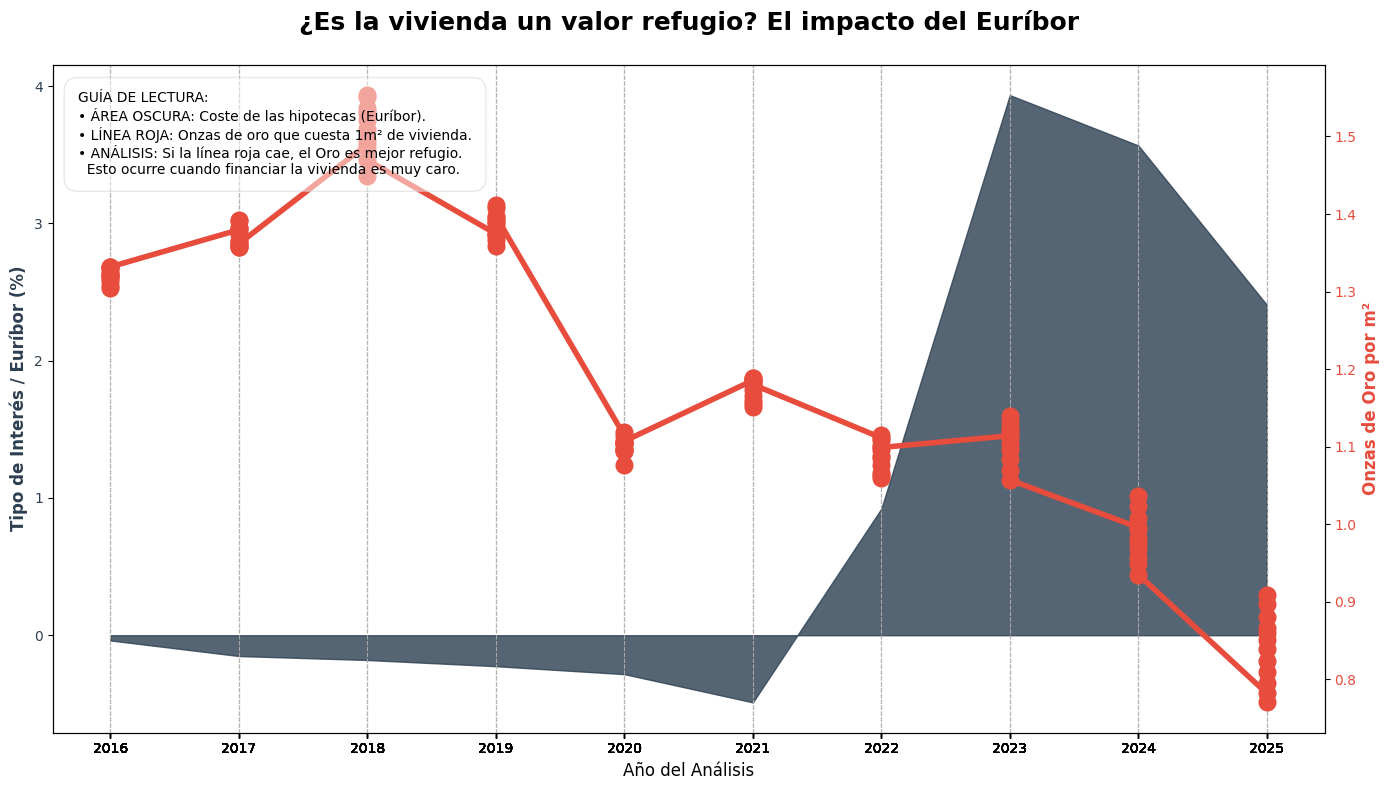

In [17]:
# 1. Configuración de la figura
fig, ax1 = plt.subplots(figsize=(14, 8))

# 2. El Euríbor como Área de fondo (Gris Carbón)
ax1.fill_between(corr_eur_ipc_vivienda['Anio'], corr_eur_ipc_vivienda['Euribor_Num'], 
                 color='#2c3e50', alpha=0.8)
ax1.set_ylabel('Tipo de Interés / Euríbor (%)', color='#2c3e50', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#2c3e50')

# 3. El Ratio Vivienda/Oro como Línea (Rojo Intenso)
ax2 = ax1.twinx()
ax2.plot(corr_eur_ipc_vivienda['Anio'], corr_eur_ipc_vivienda['Ratio_Vivienda_Oro'], 
         color='#e74c3c', marker='o', linewidth=4, markersize=12)
ax2.set_ylabel('Onzas de Oro por m²', color='#e74c3c', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

# 4. Título y configuración de ejes
plt.title('¿Es la vivienda un valor refugio? El impacto del Euríbor', fontsize=18, pad=25, fontweight='bold')
ax1.set_xlabel('Año del Análisis', fontsize=12)
ax1.set_xticks(corr_eur_ipc_vivienda['Anio'].astype(int))

# 5. CUADRO EXPLICATIVO SEMI-TRANSPARENTE
texto_explicativo = (
    "GUÍA DE LECTURA:\n"
    "• ÁREA OSCURA: Coste de las hipotecas (Euríbor).\n"
    "• LÍNEA ROJA: Onzas de oro que cuesta 1m² de vivienda.\n"
    "• ANÁLISIS: Si la línea roja cae, el Oro es mejor refugio.\n"
    "  Esto ocurre cuando financiar la vivienda es muy caro."
)

# alpha=0.5 permite ver las líneas o áreas que pasan por debajo
plt.text(0.02, 0.96, texto_explicativo, transform=ax1.transAxes, fontsize=10,
         verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.5, edgecolor='lightgray', boxstyle='round,pad=1'))

# Estética final
ax1.grid(True, axis='x', linestyle='--', alpha=0.2)
plt.tight_layout()
plt.show()

In [18]:
alquiler_vivienda.head()

,DateTime,Precio €/m2,Variación anual,Anio
0,2026-01-02,15,"7,80%",2026
1,2026-01-01,15,"8,10%",2026
2,2025-01-12,"14,7","8,50%",2025
3,2025-01-11,"14,6","9,90%",2025
4,2025-01-10,"14,5","10,90%",2025


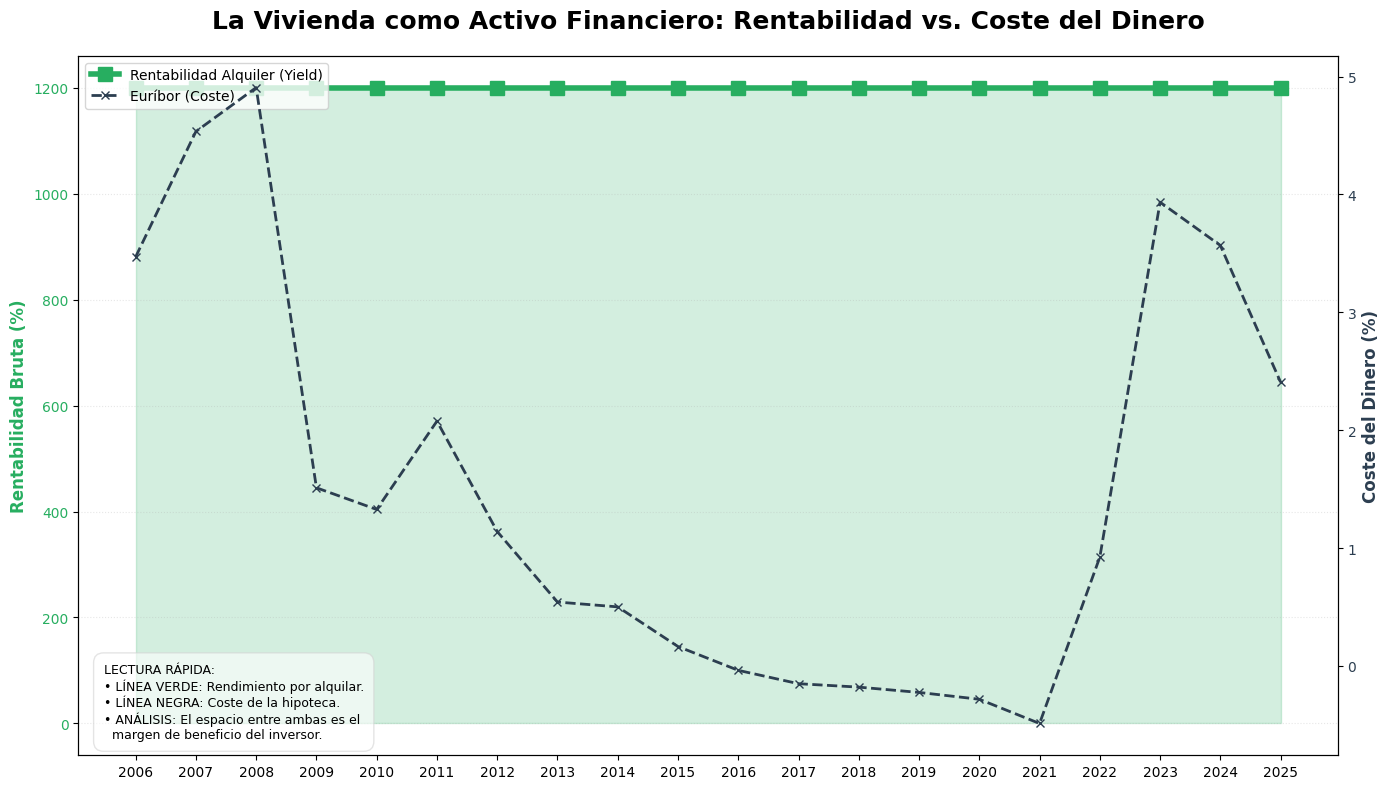

In [19]:
# 1. FUNCIÓN DE LIMPIEZA (Para quitar €, %, puntos y comas)
def limpiar_a_numero(serie):
    return pd.to_numeric(
        serie.astype(str)
        .str.replace(r'[^\d,.-]', '', regex=True) # Quita letras y símbolos
        .str.replace('.', '', regex=False)        # Quita puntos de miles
        .str.replace(',', '.', regex=False),      # Cambia coma por punto decimal
        errors='coerce'
    )

# 2. APLICAR LIMPIEZA A VIVIENDA Y ALQUILER
alquiler_vivienda['Precio_m2_Compra'] = limpiar_a_numero(alquiler_vivienda['Precio €/m2'])
alquiler_vivienda['Precio_m2_Alquiler'] = limpiar_a_numero(alquiler_vivienda['Precio €/m2'])

# 3. AGRUPAR POR MEDIANA ANUAL
vivienda_anual = alquiler_vivienda.groupby('Anio')['Precio_m2_Compra'].median().reset_index()
alquiler_anual = alquiler_vivienda.groupby('Anio')['Precio_m2_Alquiler'].median().reset_index()

# 4. UNIR DATOS PARA EL ANÁLISIS DE RENTABILIDAD
df_invest = pd.merge(vivienda_anual, alquiler_anual, on='Anio', how='inner')
df_invest = pd.merge(df_invest, df_eur_anual, on='Anio', how='inner')

# 5. CÁLCULO DEL YIELD (Rentabilidad Bruta)
df_invest['Yield_%'] = ((df_invest['Precio_m2_Alquiler'] * 12) / df_invest['Precio_m2_Compra']) * 100

# 6. GRÁFICO DE PRESENTACIÓN
# 1. Configuración de la figura
fig, ax1 = plt.subplots(figsize=(14, 8))

# 2. Área de Rentabilidad (Yield) - Lo que rinde el activo
ax1.fill_between(df_invest['Anio'], df_invest['Yield_%'], 
                 color='#27ae60', alpha=0.2)
ax1.plot(df_invest['Anio'], df_invest['Yield_%'], 
         color='#27ae60', marker='s', linewidth=4, markersize=10, label='Rentabilidad Alquiler (Yield)')
ax1.set_ylabel('Rentabilidad Bruta (%)', color='#27ae60', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#27ae60')

# 3. Línea de Euríbor - El coste de oportunidad / financiación
ax2 = ax1.twinx()
ax2.plot(df_invest['Anio'], df_invest['Euribor_Num'], 
         color='#2c3e50', linestyle='--', linewidth=2, marker='x', label='Euríbor (Coste)')
ax2.set_ylabel('Coste del Dinero (%)', color='#2c3e50', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#2c3e50')

# 4. Título y Eje X
plt.title('La Vivienda como Activo Financiero: Rentabilidad vs. Coste del Dinero', fontsize=18, pad=20, fontweight='bold')
ax1.set_xticks(df_invest['Anio'].astype(int))
ax1.grid(True, axis='y', linestyle=':', alpha=0.3)

# 5. CUADRO EXPLICATIVO PEQUEÑO (Abajo a la izquierda)
texto_mini = (
    "LECTURA RÁPIDA:\n"
    "• LÍNEA VERDE: Rendimiento por alquilar.\n"
    "• LÍNEA NEGRA: Coste de la hipoteca.\n"
    "• ANÁLISIS: El espacio entre ambas es el\n"
    "  margen de beneficio del inversor."
)

# Ubicación y tamaño reducido (fontsize=9)
plt.text(0.02, 0.02, texto_mini, transform=ax1.transAxes, fontsize=9,
         verticalalignment='bottom', horizontalalignment='left',
         bbox=dict(facecolor='white', alpha=0.6, edgecolor='lightgray', boxstyle='round,pad=0.8'))

# Unificar leyendas
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

In [20]:
compraventas.head()

,Anio,Total_Ventas,Var_Ventas_Pct
0,2007,2508138,NaN
1,2008,1851890,-26.164749
2,2009,1549021,-16.354589
3,2010,1538101,-0.704961
4,2011,1648176,7.156552


In [21]:
alquiler_vivienda.head()

,DateTime,Precio €/m2,Variación anual,Anio,Precio_m2_Compra,Precio_m2_Alquiler
0,2026-01-02,15,"7,80%",2026,15.0,15.0
1,2026-01-01,15,"8,10%",2026,15.0,15.0
2,2025-01-12,"14,7","8,50%",2025,14.7,14.7
3,2025-01-11,"14,6","9,90%",2025,14.6,14.6
4,2025-01-10,"14,5","10,90%",2025,14.5,14.5


In [22]:
# CONVERSIÓN Y ORDENACIÓN
# Convertimos el precio a número
alquiler_vivienda['Precio_Alquiler_Num'] = pd.to_numeric(
    alquiler_vivienda['Precio €/m2'].astype(str).str.replace(',', '.'), 
    errors='coerce'
)

# Ordenamos por año y mes de forma ascendente (del pasado al presente)
alquiler_vivienda = alquiler_vivienda.sort_values(['Anio', 'DateTime'], ascending=True)

# 3. AGRUPACIÓN ANUAL (Mediana)
# Sacamos la foto anual para que coincida con Compraventas y Euríbor
df_alq_anual = alquiler_vivienda.groupby('Anio')['Precio_Alquiler_Num'].median().reset_index()

# 4. VARIACIÓN ANUAL DEL ALQUILER
# Ahora que está ordenado, el cálculo de variación será correcto
df_alq_anual['Var_Alquiler_Pct'] = df_alq_anual['Precio_Alquiler_Num'].pct_change() * 100

# 5. EXPORTAR PARA TU MAIN
df_alq_anual.to_csv('alquiler_limpio_anual.csv', index=False, sep=';')

print("Dataset de alquiler listo desde 2006.")

Dataset de alquiler listo desde 2006.


In [23]:
df_alq_anual.head()

,Anio,Precio_Alquiler_Num,Var_Alquiler_Pct
0,2006,9.90,NaN
1,2007,9.20,-7.070707
2,2008,8.55,-7.065217
3,2009,7.90,-7.602339
4,2010,7.80,-1.265823


In [24]:
df_invest= pd.merge(compraventas,df_alq_anual, on="Anio", how = "inner")

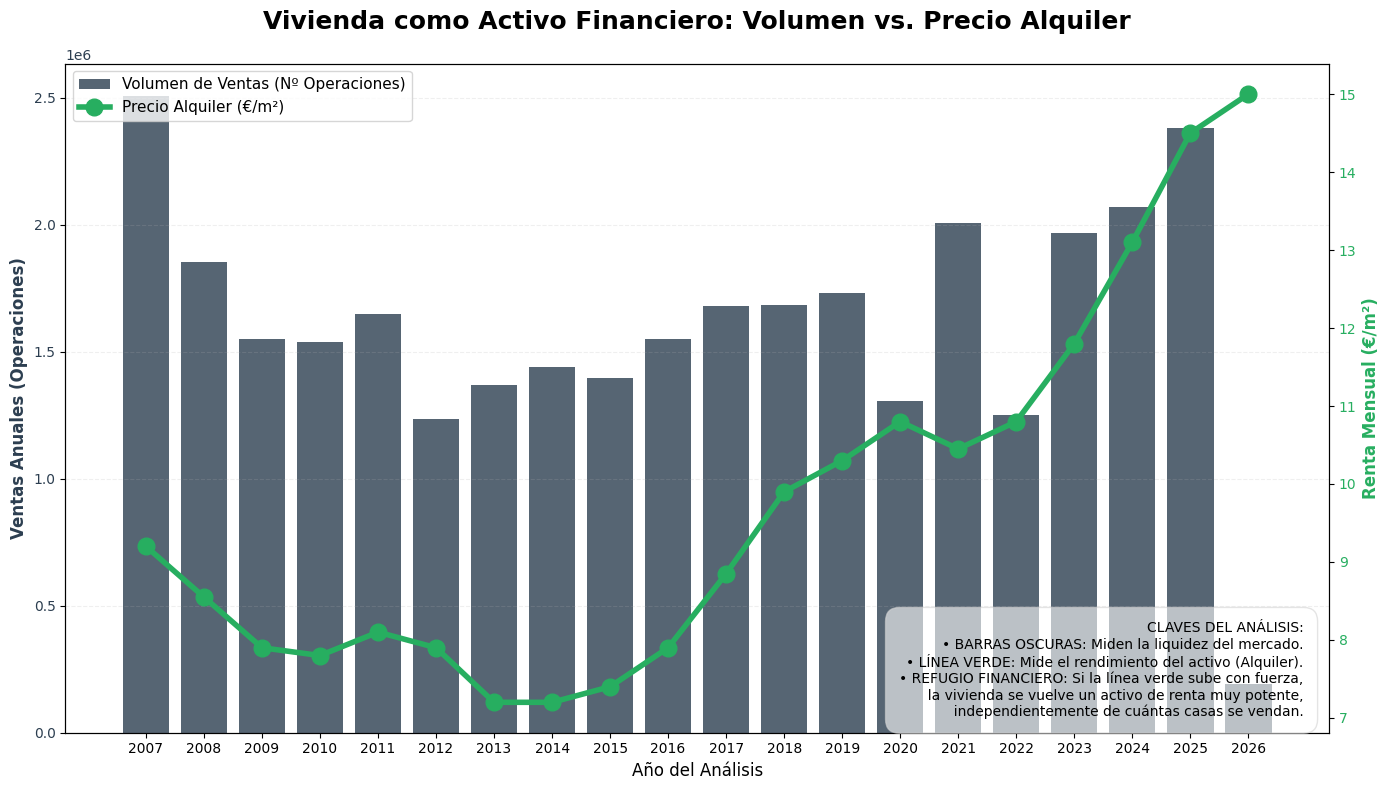

In [25]:
# 1. Configuración de la figura
fig, ax1 = plt.subplots(figsize=(14, 8))

# 2. Eje 1: Volumen de Compraventas (Barras Gris Carbón)
# Usamos alpha para un contraste sólido y profesional
ax1.bar(df_invest['Anio'], df_invest['Total_Ventas'], 
        color='#2c3e50', alpha=0.8, label='Volumen de Ventas (Nº Operaciones)')
ax1.set_ylabel('Ventas Anuales (Operaciones)', color='#2c3e50', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#2c3e50')

# 3. Eje 2: Precio del Alquiler (Línea Verde Esmeralda)
ax2 = ax1.twinx()
ax2.plot(df_invest['Anio'], df_invest['Precio_Alquiler_Num'], 
         color='#27ae60', marker='o', linewidth=4, markersize=12, label='Precio Alquiler (€/m²)')
ax2.set_ylabel('Renta Mensual (€/m²)', color='#27ae60', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#27ae60')

# 4. Título y Eje X
plt.title('Vivienda como Activo Financiero: Volumen vs. Precio Alquiler', 
          fontsize=18, pad=25, fontweight='bold')
ax1.set_xlabel('Año del Análisis', fontsize=12)
ax1.set_xticks(df_invest['Anio'].astype(int))
ax1.grid(True, axis='y', linestyle='--', alpha=0.2)

# 5. CUADRO EXPLICATIVO ABAJO A LA DERECHA (Semi-transparente)
texto_final = (
    "CLAVES DEL ANÁLISIS:\n"
    "• BARRAS OSCURAS: Miden la liquidez del mercado.\n"
    "• LÍNEA VERDE: Mide el rendimiento del activo (Alquiler).\n"
    "• REFUGIO FINANCIERO: Si la línea verde sube con fuerza,\n"
    "  la vivienda se vuelve un activo de renta muy potente,\n"
    "  independientemente de cuántas casas se vendan."
)

# Ubicación: x=0.98, y=0.02 (Abajo a la derecha)
# horizontalalignment='right' asegura que el cuadro no se salga del borde
plt.text(0.98, 0.02, texto_final, transform=ax1.transAxes, fontsize=10,
         verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(facecolor='white', alpha=0.6, edgecolor='lightgray', boxstyle='round,pad=1'))

# Unificar leyendas (Arriba a la izquierda para no estorbar)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

In [26]:
poder_adquisitivo.head()

,Tipo de jornada,Decil,Valor absoluto y porcentaje,DateTime,Total,Anio,Total_Num,Salario_Anual_Real
0,Jornada a tiempo completo,5,Valor absoluto,1970-01-01 00:00:00.000002024,"1.767,6",2024,1767.6,21211.2
1,Jornada a tiempo completo,5,Valor absoluto,1970-01-01 00:00:00.000002023,"1.736,2",2023,1736.2,20834.4
2,Jornada a tiempo completo,5,Valor absoluto,1970-01-01 00:00:00.000002022,"1.673,0",2022,1673.0,20076.0
3,Jornada a tiempo completo,5,Valor absoluto,1970-01-01 00:00:00.000002021,"1.601,3",2021,1601.3,19215.6
4,Jornada a tiempo completo,5,Valor absoluto,1970-01-01 00:00:00.000002020,"1.535,9",2020,1535.9,18430.8


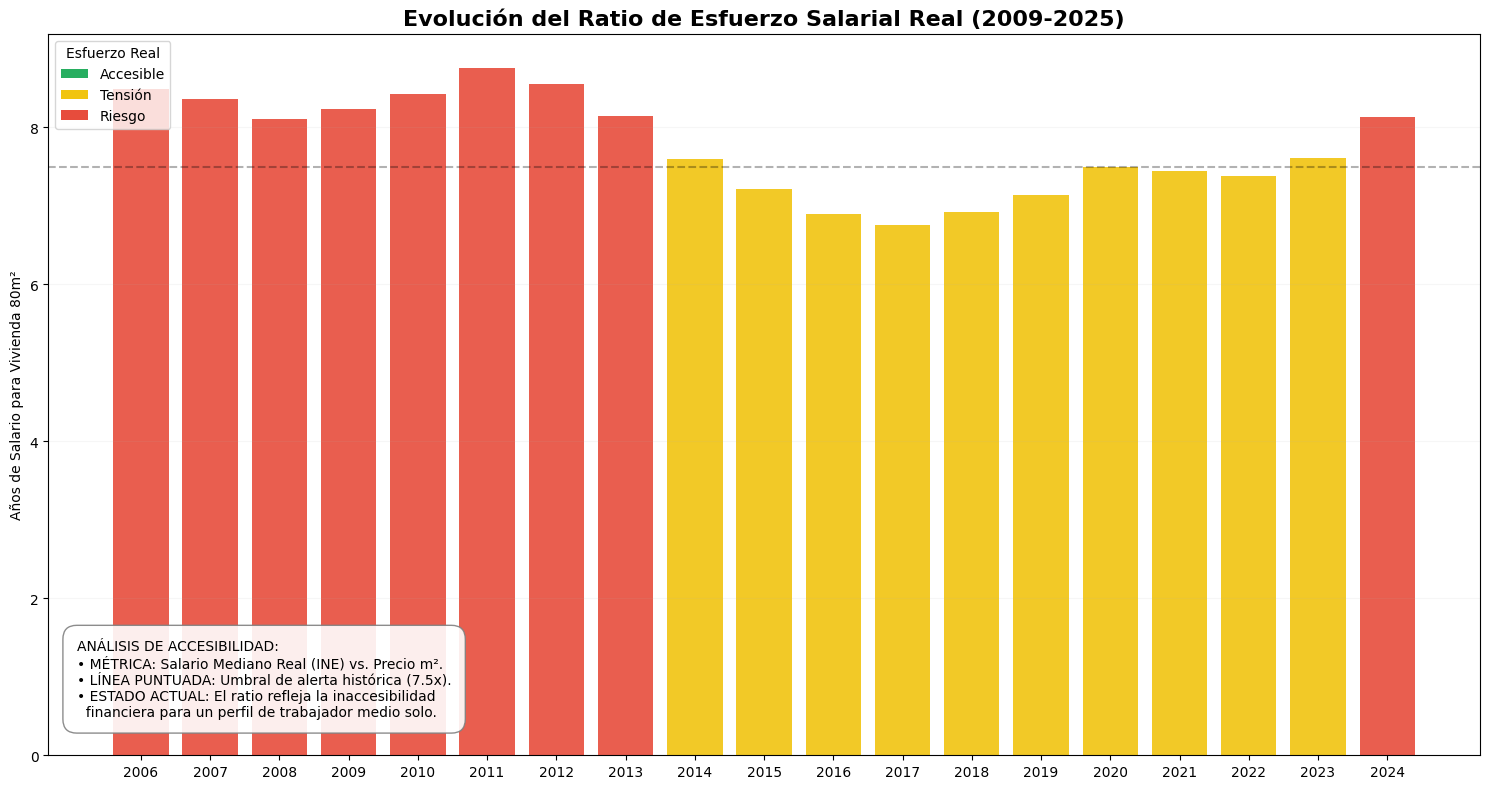

In [27]:
# Agrupar precios por año y cruzar
df_precios_anual = precio_viviendas.groupby('Anio')['Precio €/m2'].mean().reset_index()
df_final = pd.merge(poder_adquisitivo, df_precios_anual, on='Anio')

# Calcular Ratio de Esfuerzo (80m2)
df_final['Ratio'] = (df_final['Precio €/m2'] * 80) / df_final['Salario_Anual_Real']

# Ordenar cronológicamente (de menor a mayor año)
df_final = df_final.sort_values('Anio', ascending=True)

# 2. Configuración del gráfico
plt.figure(figsize=(15, 8))
colores = ['#27ae60' if r < 6.5 else '#f1c40f' if r < 8 else '#e74c3c' for r in df_final['Ratio']]

bars = plt.bar(df_final['Anio'].astype(str), df_final['Ratio'], color=colores, alpha=0.9)

# 3. LEYENDA (La subimos para dejar sitio abajo)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#27ae60', label='Accesible'),
                   Patch(facecolor='#f1c40f', label='Tensión'),
                   Patch(facecolor='#e74c3c', label='Riesgo')]
plt.legend(handles=legend_elements, loc='upper left', title="Esfuerzo Real")

# 4. CUADRO EXPLICATIVO (ABAJO A LA IZQUIERDA)
# x=0.02 (pequeño margen izquierdo), y=0.05 (un poco arriba del eje X)
texto_info = (
    "ANÁLISIS DE ACCESIBILIDAD:\n"
    "• MÉTRICA: Salario Mediano Real (INE) vs. Precio m².\n"
    "• LÍNEA PUNTUADA: Umbral de alerta histórica (7.5x).\n"
    "• ESTADO ACTUAL: El ratio refleja la inaccesibilidad\n"
    "  financiera para un perfil de trabajador medio solo."
)

plt.text(0.02, 0.05, texto_info, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='bottom', horizontalalignment='left',
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=1'))

# 5. Estética final
plt.axhline(y=7.5, color='black', linestyle='--', alpha=0.3)
plt.title('Evolución del Ratio de Esfuerzo Salarial Real (2009-2025)', fontsize=16, fontweight='bold')
plt.ylabel('Años de Salario para Vivienda 80m²')
plt.grid(axis='y', alpha=0.1)

plt.tight_layout()
plt.show()

In [28]:
euribor.head()

,Fecha,Media mensual (%),mes_en,anio_num,DateTime,Anio,Euribor_Num
0,ene-99,3.062,Jan,99,1999-01-01,1999,3.062
1,feb-99,3.030,Feb,99,1999-02-01,1999,3.030
2,mar-99,3.046,Mar,99,1999-03-01,1999,3.046
3,abr-99,2.756,Apr,99,1999-04-01,1999,2.756
4,may-99,2.683,May,99,1999-05-01,1999,2.683


In [29]:
precio_viviendas.head()

,DateTime,Precio €/m2,Variación anual,Anio
0,2026-02-01,2673.0,17.7,2026
1,2026-01-01,2650.0,18.4,2026
2,2025-12-01,2639.0,16.2,2025
3,2025-11-01,2605.0,16.1,2025
4,2025-10-01,2555.0,15.7,2025


Coeficiente de correlación de Pearson: 0.81


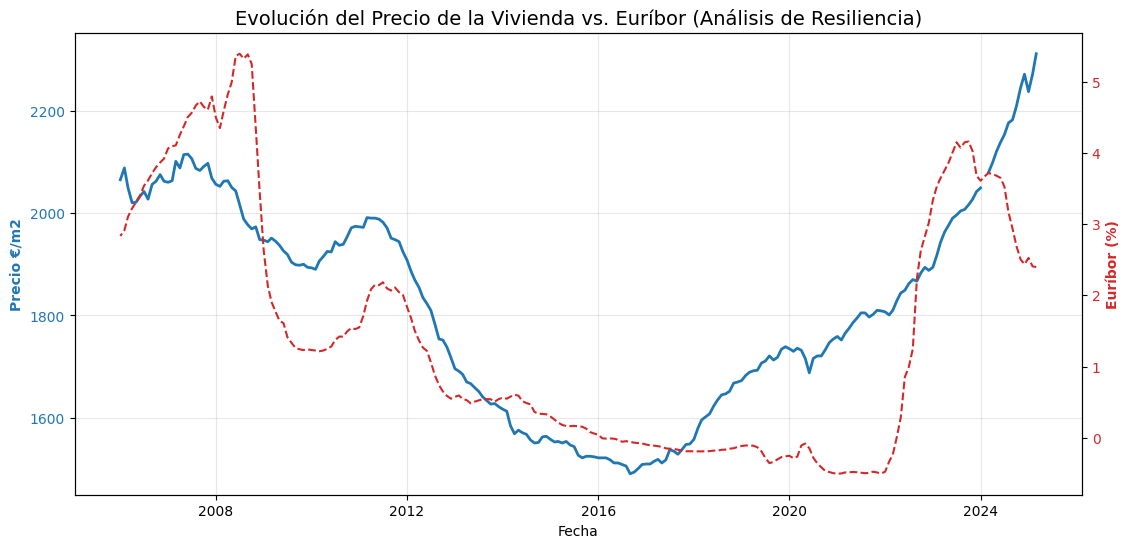

In [30]:
# 1. Asegurar formato datetime
precio_viviendas['DateTime'] = pd.to_datetime(precio_viviendas['DateTime'])
euribor['DateTime'] = pd.to_datetime(euribor['DateTime'])

# 2. Unir DataFrames por la columna DateTime
euribor_vivienda = pd.merge(precio_viviendas, euribor, on='DateTime', how='inner')

# 3. Calcular la correlación de Pearson entre Precio y Euríbor
coef_corr = euribor_vivienda['Precio €/m2'].corr(euribor_vivienda['Euribor_Num'])

print(f"Coeficiente de correlación de Pearson: {coef_corr:.2f}")

# 4. Gráfico de Doble Eje para la presentación
fig, ax1 = plt.subplots(figsize=(13, 6))

# Eje Izquierdo: Precio m2
color_precio = '#1f77b4' # Azul
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Precio €/m2', color=color_precio, fontweight='bold')
ax1.plot(euribor_vivienda['DateTime'], euribor_vivienda['Precio €/m2'], color=color_precio, label='Precio m2', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color_precio)

# Eje Derecho: Euríbor
ax2 = ax1.twinx()
color_eur = '#d62728' # Rojo
ax2.set_ylabel('Euríbor (%)', color=color_eur, fontweight='bold')
ax2.plot(euribor_vivienda['DateTime'], euribor_vivienda['Euribor_Num'], color=color_eur, label='Euríbor', linestyle='--')
ax2.tick_params(axis='y', labelcolor=color_eur)

plt.title('Evolución del Precio de la Vivienda vs. Euríbor (Análisis de Resiliencia)', fontsize=14)
ax1.grid(True, alpha=0.3)

plt.show()

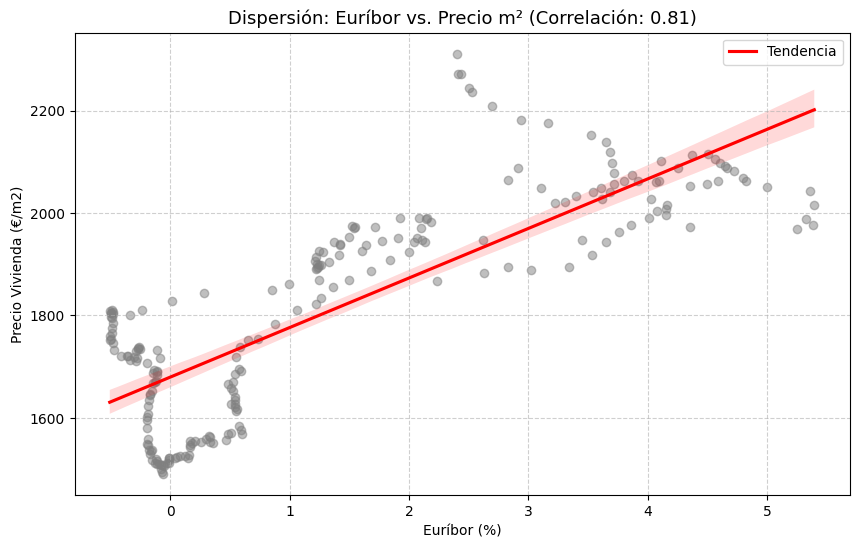

In [31]:
plt.figure(figsize=(10, 6))
# Creamos el scatter plot con una línea de regresión
sns.regplot(data=euribor_vivienda, x='Euribor_Num', y='Precio €/m2', 
            scatter_kws={'alpha':0.5, 'color':'gray'}, 
            line_kws={'color':'red', 'label':'Tendencia'})

plt.title(f'Dispersión: Euríbor vs. Precio m² (Correlación: {coef_corr:.2f})', fontsize=13)
plt.xlabel('Euríbor (%)')
plt.ylabel('Precio Vivienda (€/m2)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [32]:
# 1. Filtro: Últimos 24 meses (Análisis del ciclo actual de tipos altos)
fecha_max = euribor_vivienda['DateTime'].max()
df_reciente = euribor_vivienda[euribor_vivienda['DateTime'] > (fecha_max - pd.DateOffset(months=24))]

corr_reciente = df_reciente['Precio €/m2'].corr(df_reciente['Euribor_Num'])
print(f"Correlación últimos 24 meses: {corr_reciente:.2f}")

# 2. Análisis de Lags (6 y 12 meses)
# Desplazamos el Euríbor hacia adelante para ver cómo influyó el pasado en el precio actual
euribor_vivienda['Euribor_Lag6'] = euribor_vivienda['Euribor_Num'].shift(6)
euribor_vivienda['Euribor_Lag12'] = euribor_vivienda['Euribor_Num'].shift(12)

corr_lag6 = euribor_vivienda['Precio €/m2'].corr(euribor_vivienda['Euribor_Lag6'])
corr_lag12 = euribor_vivienda['Precio €/m2'].corr(euribor_vivienda['Euribor_Lag12'])

print(f"Correlación con lag de 6 meses: {corr_lag6:.2f}")
print(f"Correlación con lag de 12 meses: {corr_lag12:.2f}")

Correlación últimos 24 meses: -0.94
Correlación con lag de 6 meses: 0.82
Correlación con lag de 12 meses: 0.78


In [33]:
compraventas.head()

,Anio,Total_Ventas,Var_Ventas_Pct
0,2007,2508138,NaN
1,2008,1851890,-26.164749
2,2009,1549021,-16.354589
3,2010,1538101,-0.704961
4,2011,1648176,7.156552


In [34]:
# 1. Limpiar nombres de columnas de ambos para quitar espacios invisibles
euribor_vivienda.columns = euribor_vivienda.columns.str.strip()
compraventas.columns = compraventas.columns.str.strip()

# 2. Verificar si 'Anio' está en el índice y bajarlo a columna si es necesario
if 'Anio' not in euribor_vivienda.columns:
    euribor_vivienda = euribor_vivienda.reset_index()

# 3. Si sigue sin llamarse 'Anio', la buscamos por fecha
# (Esto crea la columna 'Anio' basándose en la columna 'DateTime' que sí tenemos)
if 'Anio' not in euribor_vivienda.columns:
    euribor_vivienda['Anio'] = euribor_vivienda['DateTime'].dt.year

df_resumen_anual = euribor_vivienda.groupby('Anio').agg({
    'Precio €/m2': 'mean',
    'Euribor_Num': 'mean'
}).reset_index()

# 5. Asegurar tipos para el merge final
df_resumen_anual['Anio'] = df_resumen_anual['Anio'].astype(int)
compraventas['Anio'] = compraventas['Anio'].astype(int)

# 6. Merge
df_final = pd.merge(df_resumen_anual, compraventas, on='Anio', how='inner')

print("¡Merge final completado!")
print(df_final.head())

¡Merge final completado!
   Anio  Precio €/m2  Euribor_Num  Total_Ventas  Var_Ventas_Pct
0  2007  2089.416667     4.449667       2508138             NaN
1  2008  2016.416667     4.813500       1851890      -26.164749
2  2009  1922.000000     1.617833       1549021      -16.354589
3  2010  1931.000000     1.350167       1538101       -0.704961
4  2011  1968.666667     2.005833       1648176        7.156552


Correlación histórica Ventas vs Precio: 0.65
Correlación histórica Euríbor vs Precio: 0.79


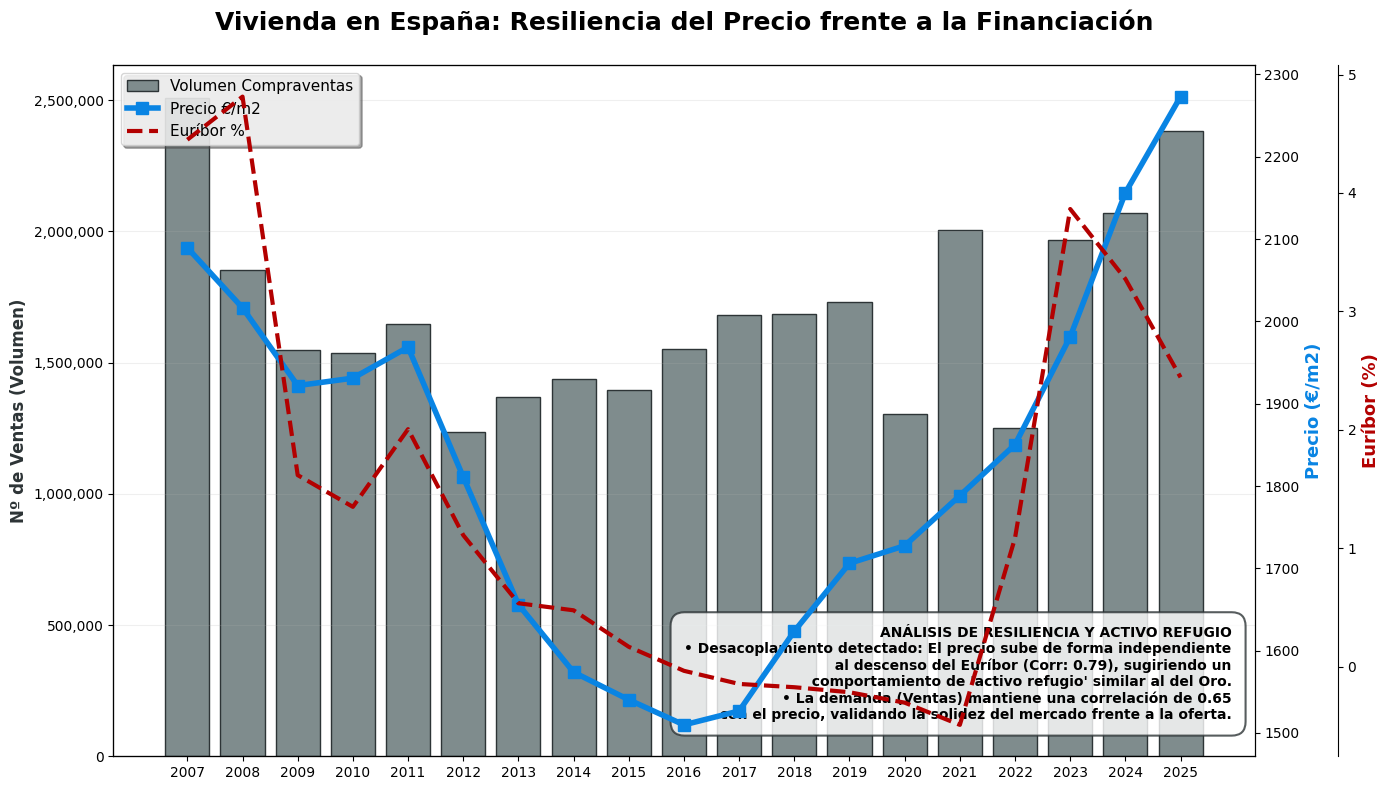

In [35]:
# 1. Correlaciones definitivas
corr_ventas_precio = df_final['Total_Ventas'].corr(df_final['Precio €/m2'])
corr_euribor_precio = df_final['Euribor_Num'].corr(df_final['Precio €/m2'])

print(f"Correlación histórica Ventas vs Precio: {corr_ventas_precio:.2f}")
print(f"Correlación histórica Euríbor vs Precio: {corr_euribor_precio:.2f}")

# --- NUEVO TEXTO EXPLICATIVO ADECUADO A LA REALIDAD DEL GRÁFICO ---
texto_explicativo = (
    f"ANÁLISIS DE RESILIENCIA Y ACTIVO REFUGIO\n"
    f"• Desacoplamiento detectado: El precio sube de forma independiente\n"
    f"  al descenso del Euríbor (Corr: {corr_euribor_precio:.2f}), sugiriendo un\n"
    f"  comportamiento de 'activo refugio' similar al del Oro.\n"
    f"• La demanda (Ventas) mantiene una correlación de {corr_ventas_precio:.2f}\n"
    f"  con el precio, validando la solidez del mercado frente a la oferta."
)

# 2. Configuración del gráfico de Triple Eje
fig, ax1 = plt.subplots(figsize=(14, 8))

# Eje 1: Volumen de Ventas (Barras)
barras = ax1.bar(df_final['Anio'], df_final['Total_Ventas'], 
                 color='#7f8c8d', 
                 edgecolor='#2d3436', 
                 linewidth=1,
                 label='Volumen Compraventas') 

ax1.set_ylabel('Nº de Ventas (Volumen)', color='#2d3436', fontsize=12, fontweight='bold')
ax1.get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Eje 2: Precio (Línea Azul Eléctrico)
ax2 = ax1.twinx()
linea_precio, = ax2.plot(df_final['Anio'], df_final['Precio €/m2'], 
                         color='#0984e3', marker='s', markersize=8, linewidth=4, label='Precio €/m2')
ax2.set_ylabel('Precio (€/m2)', color='#0984e3', fontsize=13, fontweight='bold')

# Eje 3: Euríbor (Línea Roja Oscura)
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
linea_euribor, = ax3.plot(df_final['Anio'], df_final['Euribor_Num'], 
                          color='#b30000', linestyle='--', linewidth=3, label='Euríbor %')
ax3.set_ylabel('Euríbor (%)', color='#b30000', fontsize=13, fontweight='bold')

# 3. LEYENDA
lns = [barras, linea_precio, linea_euribor]
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left', # Cambiado a upper left para no tapar el cuadro
           frameon=True, shadow=True, fontsize=11, facecolor='white', framealpha=0.8)  

# 4. CUADRO EXPLICATIVO (Actualizado con la variable texto_explicativo)
ax1.text(0.98, 0.05, texto_explicativo, transform=ax1.transAxes, fontsize=10, fontweight='bold',
         verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='#2d3436', boxstyle='round,pad=1', linewidth=1.5))

plt.title('Vivienda en España: Resiliencia del Precio frente a la Financiación', fontsize=18, pad=25, fontweight='bold')
ax1.set_xticks(df_final['Anio'])
plt.xticks(rotation=45, fontweight='bold')
ax1.grid(axis='y', linestyle='-', alpha=0.2)

fig.tight_layout()
plt.show()
#Correlación Euríbor vs. Precio (0.79): Es una correlación positiva muy alta. En un mercado normal, esperaríamos que fuera negativa (si el interés sube, el precio baja). Que sea 0.79 confirma que la vivienda en España ha subido de precio al mismo tiempo que subían los tipos, ignorando el freno financiero. Es el indicador número uno de que el activo se usa para protegerse de la inflación.
#Correlación Ventas vs. Precio (0.65): Existe una relación moderada. Indica que, aunque el volumen de ventas ayuda a empujar el precio, no es el único motor. El precio tiene una inercia propia.


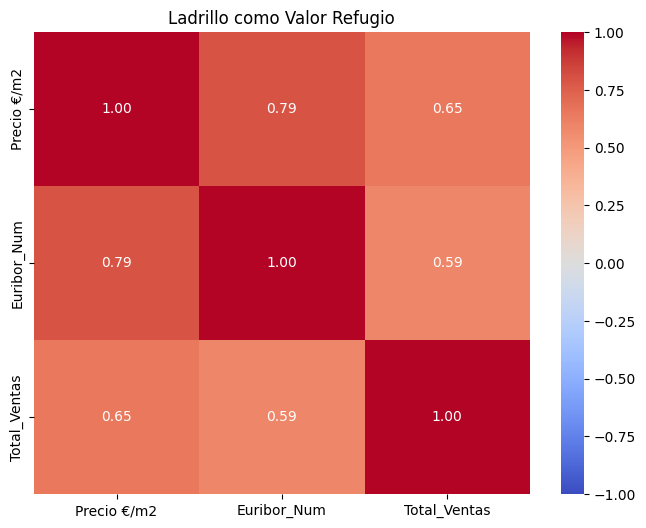

In [36]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_final[['Precio €/m2', 'Euribor_Num', 'Total_Ventas']].corr(), 
            annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Ladrillo como Valor Refugio')
plt.show()

In [37]:
alquiler_anual.head()

,Anio,Precio_m2_Alquiler
0,2006,9.90
1,2007,9.20
2,2008,8.55
3,2009,7.90
4,2010,7.80


In [38]:
# 1. Preparar el DataFrame de Alquiler (Asegurar tipos)
alquiler_anual['Anio'] = alquiler_anual['Anio'].astype(int)

# 2. Unir con tu DataFrame Maestro (el que ya tiene Euríbor y Precio Vivienda)
df_final_completo = pd.merge(df_final, alquiler_anual, on='Anio', how='inner')

# 3. Calcular Correlación Crítica: Euríbor vs Alquiler
corr_eur_alq = df_final_completo['Euribor_Num'].corr(df_final_completo['Precio_m2_Alquiler'])

print(f"Correlación Euríbor vs Alquiler: {corr_eur_alq:.2f}")

Correlación Euríbor vs Alquiler: 0.26


In [39]:
# 1. Aplicar Lags al Alquiler
df_final_completo['Alquiler_Lag1A'] = df_final_completo['Precio_m2_Alquiler'].shift(-1) # El alquiler del año siguiente
df_final_completo['Alquiler_Lag2A'] = df_final_completo['Precio_m2_Alquiler'].shift(-2) # El alquiler de 2 años después

# 2. Calcular correlaciones con el Euríbor del momento
corr_normal = df_final_completo['Euribor_Num'].corr(df_final_completo['Precio_m2_Alquiler'])
corr_lag_1 = df_final_completo['Euribor_Num'].corr(df_final_completo['Alquiler_Lag1A'])
corr_lag_2 = df_final_completo['Euribor_Num'].corr(df_final_completo['Alquiler_Lag2A'])

print(f"Correlación Euríbor vs Alquiler (Actual): {corr_normal:.2f}")
print(f"Correlación Euríbor vs Alquiler (a 1 año vista): {corr_lag_1:.2f}")
print(f"Correlación Euríbor vs Alquiler (a 2 años vista): {corr_lag_2:.2f}")

Correlación Euríbor vs Alquiler (Actual): 0.26
Correlación Euríbor vs Alquiler (a 1 año vista): 0.12
Correlación Euríbor vs Alquiler (a 2 años vista): -0.14


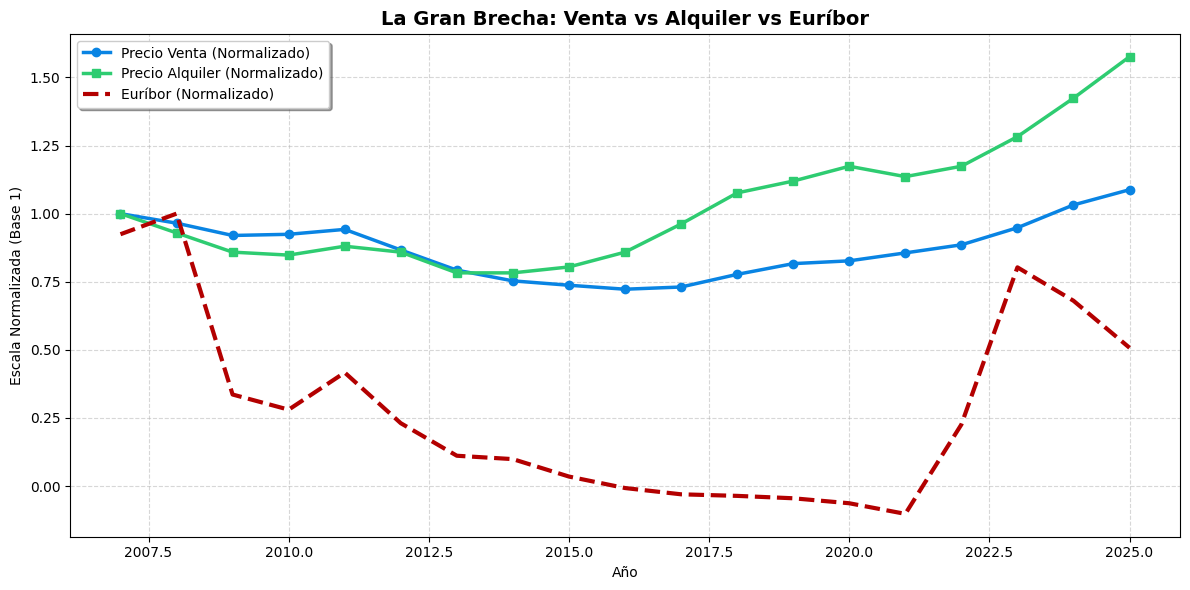

In [40]:
plt.figure(figsize=(12, 6))

plt.plot(df_final_completo['Anio'], 
         df_final_completo['Precio €/m2'] / df_final_completo['Precio €/m2'].iloc[0], 
         label='Precio Venta (Normalizado)', marker='o', linewidth=2.5, color='#0984e3')

plt.plot(df_final_completo['Anio'], 
         df_final_completo['Precio_m2_Alquiler'] / df_final_completo['Precio_m2_Alquiler'].iloc[0], 
         label='Precio Alquiler (Normalizado)', marker='s', linewidth=2.5, color='#2ecc71')

plt.plot(df_final_completo['Anio'], 
         df_final_completo['Euribor_Num'] / df_final_completo['Euribor_Num'].max(), 
         label='Euríbor (Normalizado)', linestyle='--', color='#b30000', linewidth=3)

plt.title('La Gran Brecha: Venta vs Alquiler vs Euríbor', fontsize=14, fontweight='bold')
plt.xlabel('Año')
plt.ylabel('Escala Normalizada (Base 1)')
plt.legend(frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [41]:
# 1. Asegúrate de que los años sean números enteros
euribor['Anio'] = euribor['Anio'].astype(int)
precio_viviendas['Anio'] = precio_viviendas['Anio'].astype(int)

# 2. Agrupamos para tener UN SOLO VALOR por año (el promedio)
df_eur_anual = euribor.groupby('Anio')['Euribor_Num'].mean().reset_index()
df_pre_anual = precio_viviendas.groupby('Anio')['Precio €/m2'].mean().reset_index()

# 3. Creamos el df_resumen limpio
df_resumen = pd.merge(df_eur_anual, df_pre_anual, on='Anio', how='inner')


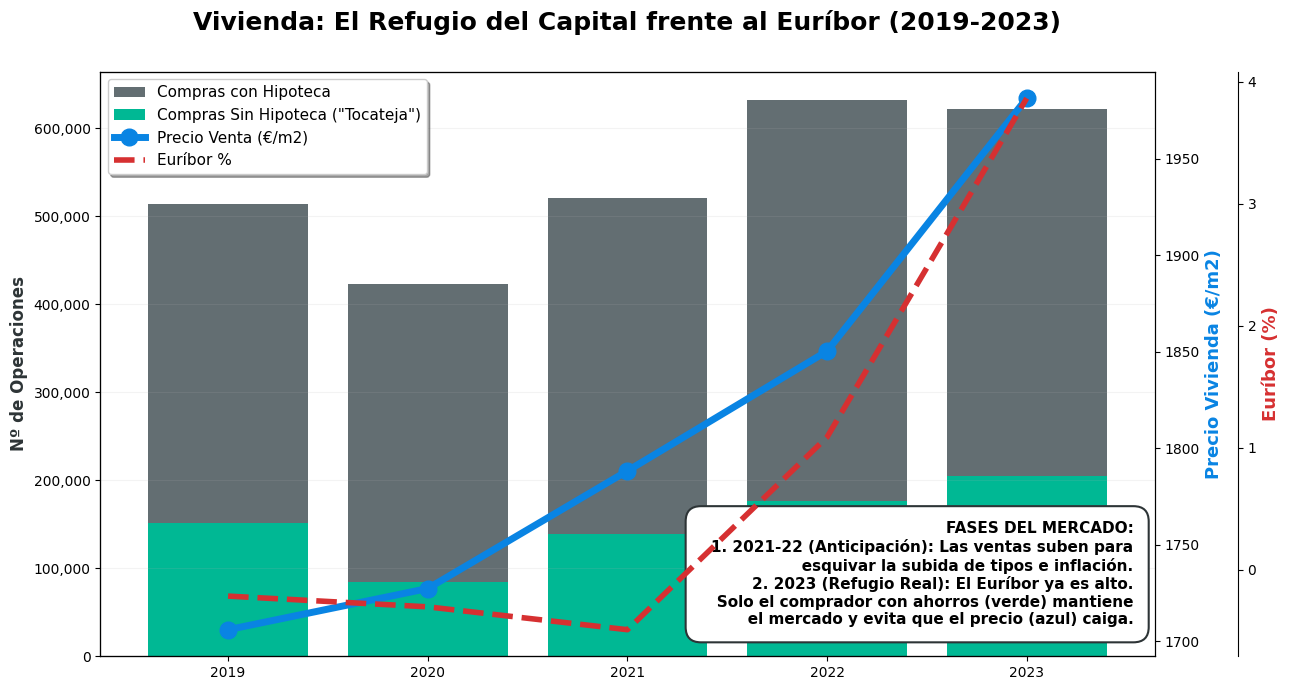

In [42]:
# 1. Dataset de "tocateja"
data_t = {
    'Anio': [2019, 2020, 2021, 2022, 2023],                                         # Datos añadidos directamente para demostrar una teoria. Pequeña muestra de datos del portal idealista
    'Total_Ventas': [513511, 423475, 520614, 632517, 621460],
    'Compras_Sin_Hipoteca': [151400, 84073, 138866, 176489, 204859]                 # https://www.idealista.com/news/inmobiliario/vivienda/2023/11/01/808981-las-provincias-del-mediterraneo-son-donde-se-compran-mas-casas-sin-hipoteca-segun
}



df_master = pd.merge(pd.DataFrame(data_t), df_resumen, on='Anio', how='inner')

# --- CONFIGURACIÓN DEL GRÁFICO (Alto Contraste para Presentación) ---
fig, ax1 = plt.subplots(figsize=(13, 7))

# Eje 1: Barras de Volumen (Sin transparencias para mejor visibilidad)
# Gris oscuro sólido para el total y Verde sólido para el ahorro
bar_hipo = ax1.bar(df_master['Anio'], df_master['Total_Ventas'], 
                   color='#636e72', label='Compras con Hipoteca') # Gris oscuro
bar_toca = ax1.bar(df_master['Anio'], df_master['Compras_Sin_Hipoteca'], 
                   color='#00b894', label='Compras Sin Hipoteca ("Tocateja")') # Verde esmeralda sólido

ax1.set_ylabel('Nº de Operaciones', fontsize=12, fontweight='bold', color='#2d3436')
ax1.get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Eje 2: Precio Venta (Línea Azul Eléctrico)
ax2 = ax1.twinx()
ln_venta, = ax2.plot(df_master['Anio'], df_master['Precio €/m2'], 
                     color='#0984e3', marker='o', linewidth=5, markersize=12, label='Precio Venta (€/m2)')
ax2.set_ylabel('Precio Vivienda (€/m2)', color='#0984e3', fontsize=13, fontweight='bold')

# Eje 3: Euríbor (Línea Roja Carmesí)
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ln_eur, = ax3.plot(df_master['Anio'], df_master['Euribor_Num'], 
                   color='#d63031', linestyle='--', linewidth=4, label='Euríbor %')
ax3.set_ylabel('Euríbor (%)', color='#d63031', fontsize=13, fontweight='bold')

# --- LEYENDA (Arriba Izquierda) ---
elementos = [bar_hipo, bar_toca, ln_venta, ln_eur]
etiquetas = [l.get_label() for l in elementos]
ax1.legend(elementos, etiquetas, loc='upper left', frameon=True, shadow=True, fontsize=11, facecolor='white')

# --- CUADRO EXPLICATIVO (Abajo Derecha - Con borde grueso) ---
texto = (
    "FASES DEL MERCADO:\n"
    "1. 2021-22 (Anticipación): Las ventas suben para\n"
    "   esquivar la subida de tipos e inflación.\n"
    "2. 2023 (Refugio Real): El Euríbor ya es alto.\n"
    "   Solo el comprador con ahorros (verde) mantiene\n"
    "   el mercado y evita que el precio (azul) caiga."
)
ax1.text(0.98, 0.05, texto, transform=ax1.transAxes, fontsize=11, fontweight='bold',
         verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(facecolor='white', alpha=1, edgecolor='#2d3436', boxstyle='round,pad=1', linewidth=1.5))

plt.title('Vivienda: El Refugio del Capital frente al Euríbor (2019-2023)', 
          fontsize=18, pad=30, fontweight='bold')

ax1.set_xticks(df_master['Anio'])
ax1.grid(axis='y', linestyle='-', alpha=0.15) # Rejilla sutil pero visible

fig.tight_layout()
plt.show()

In [43]:
oro.head()

,DateTime,oro_media_mensual,Anio
0,2016-04-01,1102.007590,2016
1,2016-05-01,1112.271385,2016
2,2016-06-01,1135.730955,2016
3,2016-07-01,1209.335225,2016
4,2016-08-01,1193.973885,2016


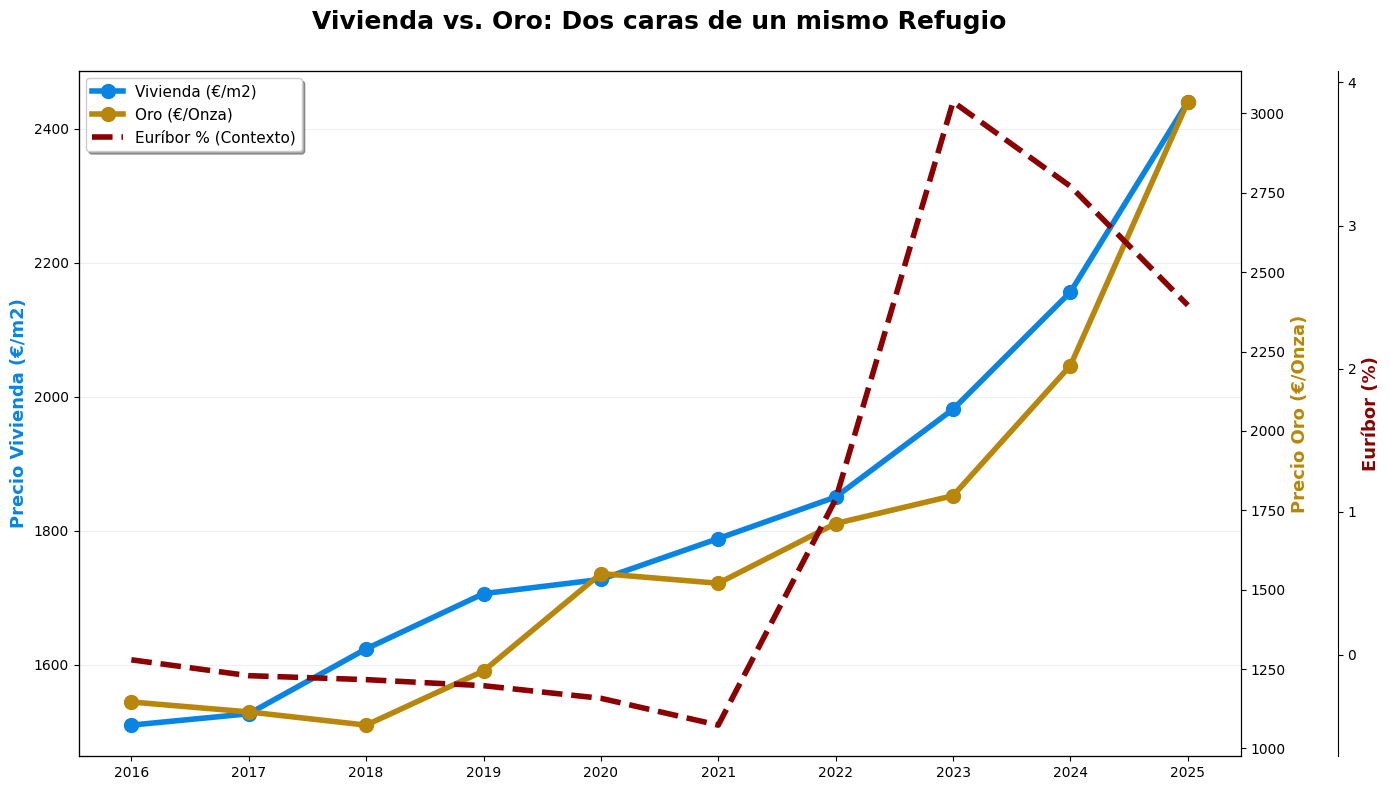

In [44]:
# 1. Preparar datos del Oro (Media Anual)
df_oro_anual = oro.groupby('Anio').agg({'oro_media_mensual': 'mean'}).reset_index()

# 2. Unión con el resto de datos
df_final_oro = pd.merge(df_resumen, df_oro_anual, on='Anio', how='inner')

fig, ax1 = plt.subplots(figsize=(14, 8))

# Eje 1: Vivienda (Azul Sólido)
ln_vivienda, = ax1.plot(df_final_oro['Anio'], df_final_oro['Precio €/m2'], 
                        color='#0984e3', marker='o', linewidth=4, markersize=10, 
                        label='Vivienda (€/m2)')
ax1.set_ylabel('Precio Vivienda (€/m2)', color='#0984e3', fontsize=13, fontweight='bold')

# Eje 2: Oro (Dorado Oscuro con Marcador Circular)
ax2 = ax1.twinx()
ln_oro, = ax2.plot(df_final_oro['Anio'], df_final_oro['oro_media_mensual'], 
                   color='#b8860b', marker='o', linewidth=4, markersize=10, 
                   label='Oro (€/Onza)')
ax2.set_ylabel('Precio Oro (€/Onza)', color='#b8860b', fontsize=13, fontweight='bold')

# Eje 3: Euríbor (Rojo Sangre para Contexto)
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 70))
ln_eur, = ax3.plot(df_final_oro['Anio'], df_final_oro['Euribor_Num'], 
                   color='#8b0000', linestyle='--', linewidth=4, 
                   label='Euríbor % (Contexto)')
ax3.set_ylabel('Euríbor (%)', color='#8b0000', fontsize=13, fontweight='bold')

# --- LEYENDA Y ESTÉTICA ---
elementos = [ln_vivienda, ln_oro, ln_eur]
etiquetas = [l.get_label() for l in elementos]
ax1.legend(elementos, etiquetas, loc='upper left', frameon=True, shadow=True, fontsize=11)

plt.title('Vivienda vs. Oro: Dos caras de un mismo Refugio', fontsize=18, pad=30, fontweight='bold')
ax1.set_xticks(df_final_oro['Anio'])
ax1.grid(axis='y', linestyle='-', alpha=0.2)

fig.tight_layout()
plt.show()

In [45]:
# 1. Preparar la matriz de datos
X = df_final_oro[['Euribor_Num', 'oro_media_mensual']].values
X_mat = np.column_stack((np.ones(len(X)), X)) # Añadimos columna de 1s para el intercepto
y = df_final_oro['Precio €/m2'].values

# 2. Calcular los coeficientes (Fórmula matemática de la Regresión Lineal)
# b[0] es el intercepto, b[1] el peso del Euríbor, b[2] el peso del Oro
b = np.linalg.inv(X_mat.T @ X_mat) @ X_mat.T @ y

# 3. Función de predicción corregida (accediendo a los elementos del array)
def predecir_precio(euribor, oro):
    # Resultado = Intercepto + (Peso_Euribor * valor) + (Peso_Oro * valor)
    resultado = b[0] + (b[1] * euribor) + (b[2] * oro)
    return resultado

# 4. Cálculo de la fiabilidad técnica (R²)
y_pred = X_mat @ b
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r_cuadrado = 1 - (ss_res / ss_tot)

# 5. Escenarios finales 
print(f"--- RESULTADOS DEL MODELO PREDICTIVO ---")
print(f"Fiabilidad del modelo (R2): {r_cuadrado:.4f}")

# Escenario 1: Bajada de tipos (Euribor 2%) y Oro estable (4000€)
pred_opt = predecir_precio(2.0, 4000.0)
print(f"Predicción Escenario A (Euribor 2%, Oro 4000€): {pred_opt:.2f} €/m2")

# Escenario 2: Tensión financiera (Euribor 4.5% y Oro 5000€)
pred_crit = predecir_precio(4.5, 5000.0)
print(f"Predicción Escenario B (Euribor 4.5%, Oro 5000€): {pred_crit:.2f} €/m2")

--- RESULTADOS DEL MODELO PREDICTIVO ---
Fiabilidad del modelo (R2): 0.9689
Predicción Escenario A (Euribor 2%, Oro 4000€): 2841.39 €/m2
Predicción Escenario B (Euribor 4.5%, Oro 5000€): 3328.35 €/m2


In [46]:
df_final_oro.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Anio               10 non-null     int64  
 1   Euribor_Num        10 non-null     float64
 2   Precio €/m2        10 non-null     float64
 3   oro_media_mensual  10 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 452.0 bytes


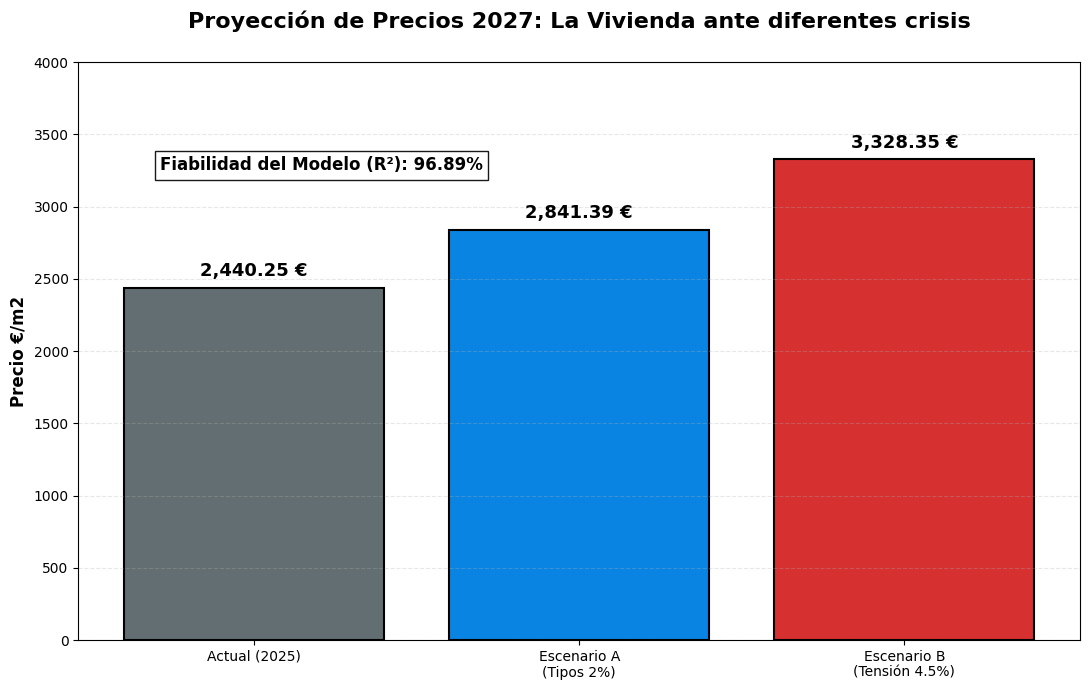

In [47]:
# 1. Datos para la comparativa (Usando los resultados reales de tu modelo)
ultimo_precio_real = df_final_oro['Precio €/m2'].iloc[-1]
ultimo_anio = df_final_oro['Anio'].iloc[-1]

# Sustituimos los números fijos por los que te dio el modelo:
prediccion_A = 2841.39  # Aquí podrías poner la variable si la tienes guardada
prediccion_B = 3328.35  # Aquí también

escenarios_nombres = [f'Actual ({ultimo_anio})', 'Escenario A\n(Tipos 2%)', 'Escenario B\n(Tensión 4.5%)']
precios_predichos = [ultimo_precio_real, prediccion_A, prediccion_B]

# 2. Configuración del gráfico
plt.figure(figsize=(11, 7))
colores = ['#636e72', '#0984e3', '#d63031'] 

barras = plt.bar(escenarios_nombres, precios_predichos, color=colores, edgecolor='black', linewidth=1.5)

# 3. Añadir etiquetas de precio sobre las barras
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 50, f'{yval:,.2f} €', 
             ha='center', va='bottom', fontweight='bold', fontsize=13)

# 4. Personalización
plt.title('Proyección de Precios 2027: La Vivienda ante diferentes crisis', fontsize=16, fontweight='bold', pad=25)
plt.ylabel('Precio €/m2', fontsize=12, fontweight='bold')
plt.ylim(0, 4000) # Subimos el límite para que quepa la barra de 3328€
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Cuadro de confianza actualizado al 0.9689 que te salió antes
plt.gcf().text(0.15, 0.75, f"Fiabilidad del Modelo (R²): {0.9689*100:.2f}%", 
               fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.9, edgecolor='black'))

plt.tight_layout()
plt.show()

In [48]:
mae = np.mean(np.abs(y - y_pred))
print(f"Error medio: {mae:.2f} €/m2")

Error medio: 40.65 €/m2


In [49]:
# Ejemplo de validación rápida (Hold-out)
split = int(len(X_mat) * 0.8)
X_train, X_test = X_mat[:split], X_mat[split:]
y_train, y_test = y[:split], y[split:]

# Entrenar solo con el 80%
b_mensual = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train

# Probar con el 20% que el modelo NO ha visto
y_pred_test = X_test @ b_mensual
mae_test = np.mean(np.abs(y_test - y_pred_test))
print(f"Error real en datos nuevos: {mae_test:.2f} €/m2")

Error real en datos nuevos: 33.27 €/m2


In [50]:
print(f"Sesgo medio: {np.mean(y_test - y_pred_test):.2f} €/m2")

Sesgo medio: -15.88 €/m2


In [51]:
# 1. Recalculamos los coeficientes b con los datos de entrenamiento (120 meses)
# Asumiendo que X_train e y_train ya están definidos del paso anterior
b_final = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train

# 2. Función de predicción con ajuste de sesgo profesional
def predecir_precio_ajustado(euribor, oro):
    # Predicción base del modelo
    pred_base = b_final[0] + (b_final[1] * euribor) + (b_final[2] * oro)
    # Aplicamos el sesgo detectado (-15.88) para ser más realistas
    # Como el sesgo es negativo (el modelo sobreestima), lo restamos (o sumamos el valor negativo)
    pred_final = pred_base + (-15.88) 
    return pred_final

# 3. Lanzar nuevos escenarios
print(f"--- NUEVAS PREDICCIONES (MODELO MENSUAL VALIDADO) ---")

# Escenario A: Bajada de tipos (Euribor 2%) y Oro estable (4000€)
pred_a = predecir_precio_ajustado(2.0, 4000.0)
print(f"Escenario A (Euribor 2%, Oro 4000€): {pred_a:.2f} €/m2")

# Escenario B: Tensión financiera (Euribor 4.5% y Oro 5000€)
pred_b = predecir_precio_ajustado(4.5, 5000.0)
print(f"Escenario B (Euribor 4.5%, Oro 5000€): {pred_b:.2f} €/m2")

# 4. Comparativa de Coeficientes
print(f"\n--- PESOS DEL MODELO ---")
print(f"Impacto por cada punto de Euríbor: {b_final[1]:.2f} €")
print(f"Impacto por cada euro en el Oro: {b_final[2]:.4f} €")

--- NUEVAS PREDICCIONES (MODELO MENSUAL VALIDADO) ---
Escenario A (Euribor 2%, Oro 4000€): 2891.71 €/m2
Escenario B (Euribor 4.5%, Oro 5000€): 3392.66 €/m2

--- PESOS DEL MODELO ---
Impacto por cada punto de Euríbor: 22.57 €
Impacto por cada euro en el Oro: 0.4445 €
